<a href="https://colab.research.google.com/github/renuka2929-tech/LP5-Practicals/blob/main/DL2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving letter-recognition.csv to letter-recognition (1).csv

Dataset:

  letter  x-box  y-box  width  height  onpix  x-bar  y-bar  x2bar  y2bar  \
0      U      0     11      8       7      8     14      7      8     13   
1      E     11     10      2      15      5      2      2      7      6   
2      R     10      1     14      15      7      0     15      1     11   
3      X      6      6      5      13      0      0     10      6      2   
4      T     10     14      8      14      9      0     14      3     15   

   xybar  x2ybr  xy2br  x-ege  xegvy  y-ege  yegvx  
0      7      9      1      7     13     15     12  
1     14      8     14      1     13     15      7  
2      9      7      4      8      9     10      6  
3      4      8      1      6      9     13      5  
4      9     11      7      7     15     14     11  
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - accuracy: 0.0625 - loss: 3.3127 - val_accuracy: 0.0000e+00 - val_loss: 3.2747
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0625 - loss: 3.2341 - val_accuracy: 0.0000e+00 - val_loss: 3.2756
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0781 - loss: 3.1696 - val_accuracy: 0.0000e+00 - val_loss: 3.2780
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1562 - loss: 3.1037 - val_accuracy: 0.0000e+00 - val_loss: 3.2797
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.1875 - loss: 3.0431 - val_accuracy: 0.0000e+00 - val_loss: 3.2826
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2031 - loss: 2.9878 - val_accuracy: 0.0000e+00 - val_loss: 3.2844
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.2812 - loss: 2.9295 - val_accuracy: 0.0000e+00 - val_loss: 3.2874
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.2969 - loss: 2.8742 - val_accuracy: 0.0000e+

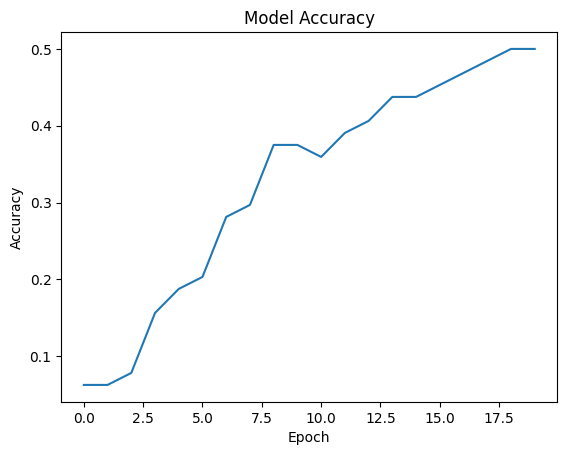


Model Saved Successfully


In [2]:
# ============================================
# Multiclass Classification using Deep Neural Network
# OCR Letter Recognition Dataset
# ============================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ============================================
# Upload CSV File
# ============================================
uploaded = files.upload()

# ============================================
# Load Dataset
# ============================================
data = pd.read_csv("letter-recognition.csv")

# Display Dataset
print("\nDataset:\n")
print(data.head())

# ============================================
# Input and Output
# ============================================

# First Column = Output Class
y = data.iloc[:, 0]

# Remaining Columns = Features
X = data.iloc[:, 1:]

# ============================================
# Encode Output Labels
# ============================================
encoder = LabelEncoder()

y = encoder.fit_transform(y)

# ============================================
# Split Dataset
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================
# Feature Scaling
# ============================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================
# Create Deep Neural Network
# ============================================
model = Sequential()

# Hidden Layer 1
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(26, activation='softmax'))

# ============================================
# Compile Model
# ============================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================
# Train Model
# ============================================
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# ============================================
# Evaluate Model
# ============================================
loss, accuracy = model.evaluate(X_test, y_test)

print("\nAccuracy:", accuracy)

# ============================================
# Predictions
# ============================================
predictions = model.predict(X_test)

# Convert Prediction Probabilities to Classes
predicted_classes = np.argmax(predictions, axis=1)

# ============================================
# Actual vs Predicted
# ============================================
print("\nActual vs Predicted:\n")

limit = min(10, len(predictions))

for i in range(limit):

    actual = encoder.inverse_transform([y_test[i]])[0]

    predicted = encoder.inverse_transform([predicted_classes[i]])[0]

    print("Actual:", actual, " Predicted:", predicted)

# ============================================
# Accuracy Graph
# ============================================
plt.plot(history.history['accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

# ============================================
# Save Model
# ============================================
model.save("ocr_letter_model.h5")

print("\nModel Saved Successfully")